In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import palettable as pal
import time
import os
import sys
import json

sns.set_context("talk",rc={"font.size":15,"axes.titlesize":15,"axes.labelsize":15})
sns.set_style("whitegrid",{"grid.color": '.9', 'grid.linestyle': '--','axes.edgecolor': '.6', 'xtick.bottom': True,'ytick.left': True})

colorTable = {}
colorTable['k'] = [0,0,0]
colorTable['g'] = [27/255,158/255,119/255]
colorTable['o'] = [217/255,95/255,2/255]
colorTable["p"] = [117/255,112/255,179/255]

from itertools import product

from Bio import SeqIO
from sklearn.decomposition import PCA
import pandas as pd

import overlappingGenes as og

# Standard genetic code
GENETIC_CODE = {
    'TTT': 'F', 'TTC': 'F', 'TTA': 'L', 'TTG': 'L',
    'TCT': 'S', 'TCC': 'S', 'TCA': 'S', 'TCG': 'S',
    'TAT': 'Y', 'TAC': 'Y', 'TAA': '*', 'TAG': '*',
    'TGT': 'C', 'TGC': 'C', 'TGA': '*', 'TGG': 'W',
    'CTT': 'L', 'CTC': 'L', 'CTA': 'L', 'CTG': 'L',
    'CCT': 'P', 'CCC': 'P', 'CCA': 'P', 'CCG': 'P',
    'CAT': 'H', 'CAC': 'H', 'CAA': 'Q', 'CAG': 'Q',
    'CGT': 'R', 'CGC': 'R', 'CGA': 'R', 'CGG': 'R',
    'ATT': 'I', 'ATC': 'I', 'ATA': 'I', 'ATG': 'M',
    'ACT': 'T', 'ACC': 'T', 'ACA': 'T', 'ACG': 'T',
    'AAT': 'N', 'AAC': 'N', 'AAA': 'K', 'AAG': 'K',
    'AGT': 'S', 'AGC': 'S', 'AGA': 'R', 'AGG': 'R',
    'GTT': 'V', 'GTC': 'V', 'GTA': 'V', 'GTG': 'V',
    'GCT': 'A', 'GCC': 'A', 'GCA': 'A', 'GCG': 'A',
    'GAT': 'D', 'GAC': 'D', 'GAA': 'E', 'GAG': 'E',
    'GGT': 'G', 'GGC': 'G', 'GGA': 'G', 'GGG': 'G'
}

def revcomp(seq):
    """Return the reverse complement of a nucleotide sequence string."""
    comp = {'A': 'T', 'T': 'A', 'G': 'C', 'C': 'G'}
    return ''.join(comp[b] for b in reversed(seq))

def get_codons_for_aa(aa):
    """Get all codons that encode a given amino acid."""
    return [codon for codon, amino_acid in GENETIC_CODE.items() if amino_acid == aa]

def get_params_and_stats(pf_name):
    if pf_name in PARAMS_CACHE:
        return PARAMS_CACHE[pf_name], NATURAL_STATS_CACHE[pf_name]
    param_file = os.path.join(BASE_DIR, pf_name, f"{pf_name}_params.dat")
    J, h = og.extract_params(param_file)
    PARAMS_CACHE[pf_name] = [J, h]
    nat_file = os.path.join(BASE_DIR, pf_name, f"{pf_name}_naturalenergies.txt")
    energies = og.load_natural_energies(nat_file)
    NATURAL_STATS_CACHE[pf_name] = (np.mean(energies), np.std(energies))
    return [J, h], (np.mean(energies), np.std(energies))


# Add current directory to path to import overlappingGenes
sys.path.append(os.getcwd())

BASE_DIR = "../../0 bmDCA"
OPTIMAL_TEMPS_FILE = "optimal_temperatures.json"

ITERATIONS = 999_999
N_TRIALS = 30

# --- Load protein families ---
ALL_PF_DIRS = sorted([d for d in os.listdir(BASE_DIR) if os.path.isdir(os.path.join(BASE_DIR, d)) and d.startswith("PF")])
print(f"Found {len(ALL_PF_DIRS)} Protein Families: {ALL_PF_DIRS}")

# --- Load optimal temperatures ---
if os.path.exists(OPTIMAL_TEMPS_FILE):
    with open(OPTIMAL_TEMPS_FILE, 'r') as f:
        OPTIMAL_TEMPS = json.load(f)
else:
    OPTIMAL_TEMPS = {}

# Precompute params and stats for all PFs (to avoid repeated file IO in workers)
PARAMS_CACHE = {}
NATURAL_STATS_CACHE = {}
for pf in ALL_PF_DIRS:
    params, stats = get_params_and_stats(pf)
    PARAMS_CACHE[pf] = params
    NATURAL_STATS_CACHE[pf] = stats



Found 3 Protein Families: ['PF00004', 'PF00041', 'PF00072']


# PF00004 and PF00072

In [3]:
aa_list = list("ACDEFGHIKLMNPQRSTVWY-")
aa_to_int = {aa: i for i, aa in enumerate(aa_list)}

pf1 = "PF00004"  # Fibronectin type II domain
pf2 = "PF00072"  # Response regulator

params1, (nat_mean1, nat_std1) = PARAMS_CACHE[pf1], NATURAL_STATS_CACHE[pf1]
params2, (nat_mean2, nat_std2) = PARAMS_CACHE[pf2], NATURAL_STATS_CACHE[pf2]
t1 = float(OPTIMAL_TEMPS.get(pf1, 1.0))
t2 = float(OPTIMAL_TEMPS.get(pf2, 1.0))
len1 = len(params1[1]) // 21
len2 = len(params2[1]) // 21

numiterations = 5000000

# Length of sequence 1
hvec = params1[1]
len1 = len(hvec) / 21
print(f"Length of sequence 1: {len1} amino acids or 3 x {len1*3} nucleotides")

# Length of sequence 2
hvec = params2[1]
len2 = len(hvec) / 21
print(f"Length of sequence 2: {len2} amino acids or 3 x {len2*3} nucleotides")

# print(f"Optimal temperatures: {t1} for {pf1}, {t2} for {pf2}")

# Lengths in nucleotides
l1_nt = int(3*len1) # exclude stop
l2_nt = int(3*len2) # exclude stop

natural_energies_1 = og.load_natural_energies(os.path.join(BASE_DIR, pf1, f"{pf1}_naturalenergies.txt"))
natural_energies_2 = og.load_natural_energies(os.path.join(BASE_DIR, pf2, f"{pf2}_naturalenergies.txt"))


Length of sequence 1: 110.0 amino acids or 3 x 330.0 nucleotides
Length of sequence 2: 108.0 amino acids or 3 x 324.0 nucleotides


In [ ]:
temppairs = [(0.5, 0.5), (0.3, 0.5), (0.3, 0.3)]

ntrial = 300
overlap = 217
numiterations = 100_000

# final_energies_list_1 = []
# final_energies_list_2 = []
# best_energies_list_1 = []
# best_energies_list_2 = []

energies_1 = {}
energies_2 = {}

for t1, t2 in temppairs:
    energies_1[(t1, t2)] = []
    energies_2[(t1, t2)] = []
    for tr in range(ntrial):
        init_seq = og.initial_seq_no_stops(len1, len2, overlap, quiet=True)
        result = og.overlapped_sequence_generator_int(
            params1, params2, init_seq,
            numberofiterations=numiterations,
            whentosave=.00001,
            quiet=True,
            T1=t1, T2=t2,
            nat_mean1=nat_mean1, nat_mean2=nat_mean2,
            std_mean1=nat_std1, std_mean2=nat_std2
        )

        final_seq = result[0]
        accepted = result[1]
        energy_history_seq1 = result[2]
        energy_history_seq2 = result[3]
        final_energies = result[4]
        best_energies = result[5]
        best_seq = result[6]
        best_save_idx = result[7]

        # Split best_seq into individual sequences
        seq1_best = best_seq[:l1_nt]
        seq2_best = best_seq[-l2_nt:]

        # Split into triplets and translate
        triplets1 = [seq1_best[i:i+3] for i in range(0, len(seq1_best), 3)]
        triplets2 = [seq2_best[i:i+3] for i in range(0, len(seq2_best), 3)]

        seq1_aa = ''.join([GENETIC_CODE[triplet] for triplet in triplets1])
        seq2_aa = ''.join([GENETIC_CODE[triplet] for triplet in triplets2])

        # final_energies_list_1.append(final_energies[0])
        # final_energies_list_2.append(final_energies[1])
        # best_energies_list_1.append(best_energies[0])
        # best_energies_list_2.append(best_energies[1])

        energies_1[(t1, t2)].append(energy_history_seq1)
        energies_2[(t1, t2)].append(energy_history_seq2)

        print(f"Trial {tr+1}/{ntrial} for T1={t1}, T2={t2} completed.")

Trial 1/300 for T1=0.5, T2=0.5 completed.
Trial 2/300 for T1=0.5, T2=0.5 completed.
Trial 3/300 for T1=0.5, T2=0.5 completed.
Trial 4/300 for T1=0.5, T2=0.5 completed.
Trial 5/300 for T1=0.5, T2=0.5 completed.
Trial 6/300 for T1=0.5, T2=0.5 completed.
Trial 7/300 for T1=0.5, T2=0.5 completed.
Trial 8/300 for T1=0.5, T2=0.5 completed.
Trial 9/300 for T1=0.5, T2=0.5 completed.
Trial 10/300 for T1=0.5, T2=0.5 completed.
Trial 11/300 for T1=0.5, T2=0.5 completed.
Trial 12/300 for T1=0.5, T2=0.5 completed.
Trial 13/300 for T1=0.5, T2=0.5 completed.
Trial 14/300 for T1=0.5, T2=0.5 completed.
Trial 15/300 for T1=0.5, T2=0.5 completed.
Trial 16/300 for T1=0.5, T2=0.5 completed.
Trial 17/300 for T1=0.5, T2=0.5 completed.
Trial 18/300 for T1=0.5, T2=0.5 completed.
Trial 19/300 for T1=0.5, T2=0.5 completed.
Trial 20/300 for T1=0.5, T2=0.5 completed.
Trial 21/300 for T1=0.5, T2=0.5 completed.
Trial 22/300 for T1=0.5, T2=0.5 completed.
Trial 23/300 for T1=0.5, T2=0.5 completed.
Trial 24/300 for T1=

In [ ]:
# Long trajectories are saved in the energies_1 and energies_2 dictionaries, keyed by (T1, T2) pairs.

# Save energies to a pickle file for later plotting
import pickle
with open("20230323 PF00004_PF00072_Overlap217_EnergyTrajectories_300_1e5steps.pkl", "wb") as f:
    pickle.dump(energies_1, f)
    pickle.dump(energies_2, f)

# Load energies from pickle file
# import pickle
# with open("20260323 PF00004_PF00072_Overlap217_EnergyTrajectories_300_1e5steps.pkl", "rb") as f:
#     energies_1 = pickle.load(f)
#     energies_2 = pickle.load(f)

# temppairs = [(0.5, 0.5), (0.3, 0.5), (0.3, 0.3)]

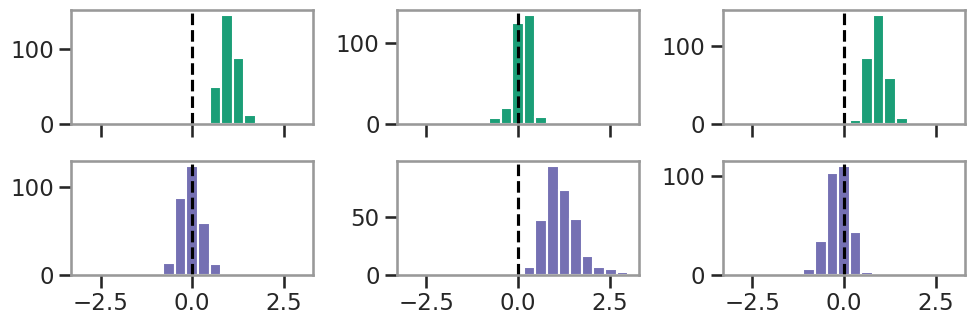

In [10]:
# Plot histogram of natural and final energies at each temperature pair

natural_energies_1 = og.load_natural_energies(os.path.join(BASE_DIR, pf1, f"{pf1}_naturalenergies.txt"))
natural_energies_2 = og.load_natural_energies(os.path.join(BASE_DIR, pf2, f"{pf2}_naturalenergies.txt"))

bins1 = np.linspace(nat_mean1 - 3*nat_std1, nat_mean1 + 3*nat_std1, 20)
bins2 = np.linspace(nat_mean2 - 3*nat_std2, nat_mean2 + 3*nat_std2, 20)

# fig, axs = plt.subplots(3,2,figsize=(6,6), sharex = "col")

fig, axs = plt.subplots(2,3,figsize=(10,3.5), sharex = True, sharey = False)


for whichpair, (t1, t2) in enumerate(temppairs):
    # fig, axs = plt.subplots(2,1,figsize=(3,3), sharex = True)

    f1 = np.array([traj[-1] for traj in energies_1[(t1, t2)]])
    f2 = np.array([traj[-1] for traj in energies_2[(t1, t2)]])

    # convert to z-scores using natural mean and std
    f1_z = (f1 - nat_mean1) / nat_std1
    f2_z = (f2 - nat_mean2) / nat_std2

    ## z-score version
    axs[0, whichpair].axvline(0, color='black', linestyle='--', label=f"{pf1} Nat Mean (z=0)")
    axs[0, whichpair].hist(f1_z, bins=np.linspace(-3,3, 20), alpha=1, color=colorTable['g'])
    axs[1, whichpair].axvline(0, color='black', linestyle='--', label=f"{pf2} Nat Mean (z=0)")
    axs[1, whichpair].hist(f2_z, bins=np.linspace(-3,3, 20), alpha=1, color=colorTable['p'])

    axs[0,whichpair].grid(False)
    axs[1,whichpair].grid(False)


plt.tight_layout()
# plt.savefig("202603 Panels/PF00004_PF00072_Overlap217_Temps_Various_EnergyHistograms_300reps_1e5steps.svg", dpi=300)